# SWIFT-FMQAによるブラックボックス最適化

[M. Nakano et al., "SWIFT-FMQA: Enhancing Factorization Machine With Quadratic-Optimization Annealing viaSliding Window," IEEE Access 14, 10977 (2026)](https://doi.org/10.1109/ACCESS.2026.3655591)

[arXiv版論文リンク](https://arxiv.org/abs/2507.21024)

## SWIFT-FMQAの概要
- Sliding window for iterative factorization training combined with FMQA (SWIFT-FMQA)は，ブラックボックス最適化手法であるfactorization machine with quadratic-optimization annealing (FMQA)[1]の拡張手法として提案された．
- スライディングウィンドウ[2][3]を用いてFMQAプロセスにおけるFMの学習データセット内のデータ数に上限値$D_{\mathrm{latest}}$を設けることで最低化性能を向上させる．

[1] [K. Kitai et al., Phys. Rev. Res., 2, 013319 (2020).](https://journals.aps.org/prresearch/abstract/10.1103/PhysRevResearch.2.013319) \
[2] [G. Widmer et al., Mach. Learn., 23, 69 (1996).](https://link.springer.com/article/10.1007/BF00116900)\
[3] [A. S. Iwashita et al., IEEE Access, 7, 1532 (2018).](https://ieeexplore.ieee.org/document/8571222)

<div align="center">
  <img src="./illust/SWIFT-FMQA_illustration.png" width="550" alt="SWIFT-FMQAの最適化プロセス"> 
  <br><br> <img src="./illust/FMQA_comparison.jpg" width="550" alt="FMQAとSWIFT-FMQAにおける学習データセットの違い">
</div>

## 背景
* FMQAでは，最適化プロセスの繰り返しによって最適解探索が停滞しやすくなることが課題として報告されている[4][5]．
* 原因として，FMQAにおけるFMの学習データセット内のデータの希釈化が挙げられる．

[4] [C. Ross et al., Int. Conf. NEMO, 99 (2023).](https://ieeexplore.ieee.org/document/10202166)\
[5] [A. Maruo et al., Int. J. Appl. Electromagn. Mech., 78, 187 (2025).](https://journals.sagepub.com/doi/abs/10.1177/13835416251328932)

データの希薄化の数式表現は次のように表される．

$$
L(\theta) = \frac{1}{D+1} \left[ \underbrace{\sum_{d=1}^{D} (f_{\mathrm{FM}}(x^{(d)}; \theta) - y^{(d)})^2}_{\text{Existing Data (Dominant)}} + \underbrace{(f_{\mathrm{FM}}(x^{(D+1)}; \theta) - y^{(D+1)})^2}_{\text{New Data (Diluted)}} \right].
$$

* $L(\theta)$: 損失関数（本項では平均二乗誤差を用いている．）
* $f_{\mathrm{FM}}$: FMのモデル式
* $\theta$: FMのモデルパラメータが格納されたベクトル
* $D$: 既存のデータセット内のデータ数
* $x^{(d)}, y^{(d)}$: データセット内の$d$番目の解とその解の目的関数値

$D$ が大きくなる（最適化の後半）につれ，係数 $1/(D+1)$ によって新規データの項（右側の項）の寄与が相対的に希釈される．その結果，損失関数の勾配が大量の過去データに支配され，FMモデルが新しい有望な解に適応できなくなる（FMモデルの慣性が高まる）．これが最適解探索停滞の一因となる．

## 手法の目的

スライディングウィンドウ戦略に基づいてFMの学習データセットを構築することで，最適化プロセスの反復過程でデータセットに追加される，「最適解探索において有望なデータ」がFMの学習に与える影響を高め，FMの学習精度およびFMQAの最適化性能を向上させること．

## SWIFT-FMQAの手順

### 入力（パラメータ名）

* $f$ (`bb_func`): 最適化対象のブラックボックス関数
* $N$ (`N`): 入力バイナリベクトルの次元数
* $N_{\mathrm{iter}}$ (`n_iter`): 最適化プロセスの総反復回数
* $D_{\mathrm{init}}$ (`n_init_data`): 初期学習データ数
* $D_{\mathrm{latest}}$ (`size_limit`): データセット内の最大データ数（スライディングウィンドウのサイズ）
* $K$ (`K`): Factorization Machine (FM) のハイパーパラメータ（ランク）

### 出力（属性名）

* $x_{\mathrm{best}}$ (`result.best.values`): $f$ を最小化（または最大化）する最良解
* $f(x_{\mathrm{best}})$ (`result.best.objective`): $x_{\mathrm{best}}$のブラックボックス関数の出力値


### アルゴリズムの手順

#### 初期学習データセットの構築

* $D_{\mathrm{init}}$ 個のランダムなバイナリベクトル $x^{(d)} \in \{0, 1\}^N$ を生成する．
* ブラックボックス関数の出力値を得る: $y^{(d)} = f(x^{(d)})$.
* 初期学習データセットを構築する: $\mathcal{D}^{(0)} \equiv \{(x^{(1)}, y^{(1)}), \dots, (x^{(D_{\mathrm{init}})}, y^{(D_{\mathrm{init}})})\}$.

#### 最適化ループ（$t=1,\dotsc , N_{\mathrm{iter}}$）

* **Step 1: FMによる機械学習**

  - データセット $\mathcal{D}^{(t-1)}$ を使用して，損失関数 $L(\theta)$ を最小化するようにFMのパラメータ $\theta = (\omega_0, \boldsymbol{\omega}, \{\boldsymbol{v}_i\}), \omega_0 \in \mathbb{R}, \boldsymbol{\omega} \in \mathbb{R}^{N}, \boldsymbol{v} \in \mathbb{R}^{N \times K}$ を学習する．
  - FMのモデル式: $f_{\mathrm{FM}}(x) = \omega_0 + \sum \omega_i x_i + \sum \langle v_i, v_j \rangle x_i x_j, \quad x_i \in \{0, 1\}$．

* **Step 2: イジングマシンによるサンプリング**
  * Step1における学習済みFMをQUBO形式に定式化する．
  * イジングマシン（Fixstars Amplify AE, quantum annealing, simulated annealing等）を使用し，QUBOのエネルギーを最小化する解 $x^*$ をサンプリングする．

* **Step 3: BB関数の呼び出し**
  * サンプリングされた解についてブラックボックス関数の出力値を得る: $y^* = f(x^*)$．
  * サブセット $\mathcal{S}^{(t)} = (x^*, y^*)$ を構築する．

* **Step 4: 学習データセットの更新**
  * データセット$\mathcal{D}^{(t)}=\mathcal{D}^{(t-1)} + \mathcal{S}^{(t)} - \mathcal{D}^{(t)}_{\mathrm{old}}$を構築する．
  * $\mathcal{D}^{(t)}_{\mathrm{old}}$ 内のデータ数を$D^{(t)}_{\mathrm{old}} = \mathrm{max}(D^{(t)} + 1 - D_{\mathrm{latest}}, 0)$とする．

#### 最良解の出力

* 今まで探索した解のうち最小解 $x_{\mathrm{best}}$ および $x_{\mathrm{best}}$ のブラックボックス関数の出力値 $f(x_{\mathrm{best}})$ を返す．

## ライブラリの使用方法

このライブラリでは，SWIFT-FMQAの実行に`amplify_bbopt`を使用する．

- `amplify_bbopt` のドキュメントは[こちら](https://amplify.fixstars.com/ja/docs/amplify-bbopt/v1/index.html)
- `amplify`のドキュメントは[こちら](https://amplify.fixstars.com/ja/docs/amplify/v1/index.html)

### 必要ライブラリの読み込み

In [10]:
import amplify_bbopt
from amplify_bbopt import (
    BinaryVariable,
    blackbox,
)
from amplify import FixstarsClient
from amplify_bbopt_ext.latest_filter import run

from datetime import timedelta
import numpy as np

In [11]:
amplify_bbopt.__version__

'1.0.3'

In [ ]:
TOKEN = "YOUR TOKEN HERE"

### ブラックボックス関数の設定

本実験では，ブラックボックス関数のベンチマークとして **Low autocorrelation binary sequences (LABS) 問題** を用いる．\
LABS問題は，レーダーのサイドローブ抑制や通信分野などに応用される組合せ最適化問題であり，系列の自己相関の二乗和を最小化することを目的とする．

長さ $N$ (`N`) のスピン変数系列 $s = (s_1, \dots, s_N)$ （ただし $s_i \in \{-1, +1\}$）に対し，自己相関関数 $C_k(\boldsymbol{s})$ は以下のように定義される．

$$
C_k(\boldsymbol{s}) = \sum_{i=1}^{N-k} s_i s_{i+k}
$$

**`N`の値は大きいほど最適解探索は困難になる.**

自己相関の二乗和 $E(\boldsymbol{s})$ は以下に示される．

$$
E(\boldsymbol{s}) = \sum_{k=1}^{N-1} C_k^2(s)
$$

また，メリットファクター $F(\boldsymbol{s})$ は以下に示される．

$$
F(\boldsymbol{s}) = \frac{N^2}{2E(s)}
$$

したがって，LABS問題は以下に定式化される．

$$
\mathrm{minimize}\ E(\boldsymbol{s}) \quad \mathrm{or} \quad \mathrm{maximize}\ F(\boldsymbol{s})
$$

本実験では $F(\boldsymbol{s})$ の最大化を目指すが，イジングマシンによる解探索の際は最小化問題として扱うため，目的関数（ブラックボックス関数）は **$-F(\boldsymbol{s})$** と定義する．

また，プログラム入力となるバイナリ変数 $x_i \in \{0, 1\}$ は，以下の変換式によってスピン変数 $s_i$ に変換されて計算される．

$$
s_i = 2x_i - 1
$$

In [13]:
# LABS問題（負符号をつけたメリットファクター）
N = 16 # 変数の個数

@blackbox
def bb_func(x: list[bool] = [BinaryVariable() for _ in range(N)]):
    ising_var = [1 if b else -1 for b in x]
    e = 0.0
    for k in range(1, N):
        v = sum(ising_var[i] * ising_var[i + k] for i in range(0, N - k))
        e += v * v
    return -N * N / (2.0 * e)

### 初期サンプル生成

- 初期学習データのための解を生成する．
- 初期学習データ数 `n_init_data` は，SWIFT-FMQAの最適化性能に大きく影響しない．
- ただし，`n_init_data` はブラックボックス関数の呼び出し回数に相当するため，大きすぎる `n_init_data` の設定はコストの増大につながる．
    - $1 \leq$ `n_init_data` $\leq 100$ 程度で問題ない．

In [14]:
n_init_data = 10 # 初期データセットのデータ数
seed = 42
rng = np.random.default_rng(seed)

initial_samples = rng.choice([0, 1], size=(n_init_data, N))

### SWIFT-FMQAの実行

In [15]:
client = FixstarsClient()
client.parameters.timeout = timedelta(milliseconds=1000)  # 1 second
client.token = TOKEN

# パラメータ調整は末尾のパラメータ設定のTipsを参照
size_limit = 200 # データセット内のデータ数の上限値
K = 8 # FMのハイパーパラメータ
n_iter = 200 # 最適化プロセスの総反復回数
epochs = 1000 # FMの1回の機械学習あたりの損失関数の勾配の更新回数
optimizer_params = {"lr": 0.01} # 学習（モデルの最適化）用のパラメータ設定．lrは学習率
lr_scheduler_class = None # 学習率スケジューリングの設定
seed = None # 初期サンプルを生成する際のシード値． Noneの場合は実行ごとに異なる乱数が生成される．

In [ ]:
result = run(
    client,
    bb_func,
    size_limit,
    K,
    n_iter,
    initial_samples,
    epochs,
    optimizer_params,
    lr_scheduler_class,
)

In [17]:
print(result.best.values)  # ベスト解（入力値）
print(result.best.objective)  # ベスト解に対応する目的関数値

{'x': [0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0]}
-3.5555555555555554


## 結果の可視化

最適化プロセスの反復に対する，探索解のブラックボックス関数の出力値の推移を表す．

- 青色プロット: 初期学習データにおけるブラックボックス関数の出力値
- 赤色プロット: イジングマシンが探索した解のブラックボックス関数の出力値

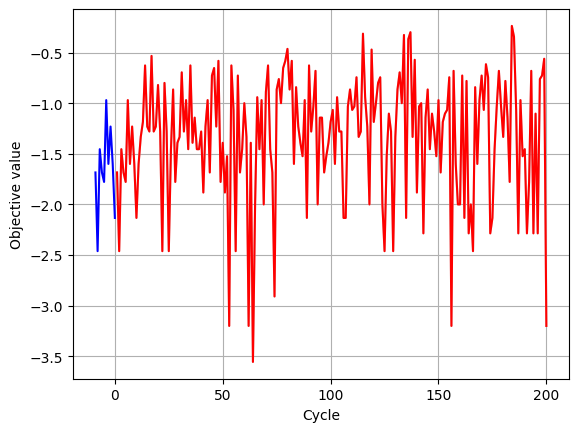

In [18]:
import matplotlib.pyplot as plt

# 初期学習データ
objectives_init = result.training_data.y[:n_init_data]

# アニーリングから直接得られたベスト解の履歴
objectives_annealing_best = [
    float(h.annealing_best_solution.objective) for h in result.history
]

# フォールバック解も含めた最良解の履歴
objectives_all = [
    float(h.annealing_new_solution.objective)
    if h.fallback_solution is None
    else float(h.fallback_solution.objective)
    for h in result.history
]

plt.plot(range(-n_init_data + 1, 1), objectives_init, "blue")
plt.plot(range(1, len(objectives_all) + 1), objectives_all, "lightgrey")
plt.plot(range(1, len(objectives_annealing_best) + 1), objectives_annealing_best, "-r")

plt.xlabel("Cycle")
plt.ylabel("Objective value")

plt.grid(True)

## パラメータ設定のTips

- `size_limit`: SWIFT-FMQAにおけるデータセット内のデータ数の上限値 $D_{\mathrm{latest}}$ を表す．
    - `size_limit` が大きいほど，FMの学習における汎化性能は高まる．一方で，`size_limit` が 大きすぎるとFMの学習における新規データの希釈化が進み，新規データに対するFMの学習の追従性が低下する．FMの汎化性能と新規データへの追従性はトレードオフの関係にあり，両者を両立する `size_limit` の設定が要求される．
    - LABS問題のメリットファクターの最大化問題においては以下の`size_limit`設定が最適である．
        - $N=16$: `size_limit` $\approx$ 200
        - $N=49$: `size_limit` $\approx$ 100
        - $N=64$: `size_limit` $\approx$ 100
        - $N=81$: `size_limit` $\approx$ 50
        - $N=101$: `size_limit` $\approx$ 10

        $N$の増加に伴って，最適な `size_limit` は減少する傾向にある．

- `K`: FMのハイパーパラメータを表す．
    - SWIFT-FMQAにおいては `K` の値は最適化性能に大きく影響しない．
    - ただし，`K` が大きすぎると，過学習や計算量の増大につながるため，適切な設定が要求される．
        - $8 \leq$ `K` $\leq 10$が適切である．
        

- `n_iter`: 最適化プロセスの総反復回数を表す．
    - $N$ によって最適な `n_iter` は異なる．以下の目安に従うと解探索のある程度十分な収束が見込める．
        - $N=16$: `n_iter` $\approx 1000$
        - $N=49$: `n_iter` $\approx 2000$
        - $N=64$: `n_iter` $\approx 4000$
        - $N=81$: `n_iter` $\geq 4000$
        - $N=101$: `n_iter` $\geq 4000$

        $N$の増加に伴って，最適な `n_iter` は増加する傾向にある．

- `epochs`: FMの1回の機械学習あたりの損失関数の勾配の更新回数を表す．
    - `n_iter`が大きいほどFMの学習に時間がかかる．
    - `n_iter` を十分に取ることができれば `epochs` $=1000$で十分である．
    - `epochs` $=2000$で十分な学習の収束が見込める．

- `lr`: FMの1回の機械学習における学習率を表す．
    - `lr` $=0.01$ で十分な学習の収束が見込める．

## SWIFT-FMQAの引用

```bibtex
@article{nakano2026swift,
  author={Nakano, Mayumi and Seki, Yuya and Kikuchi, Shuta and Tanaka, Shu},
  journal={IEEE Access}, 
  title={SWIFT-FMQA: Enhancing Factorization Machine With Quadratic-Optimization Annealing via Sliding Window}, 
  year={2026},
  volume={14},
  number={},
  pages={10977-10990},
  doi={10.1109/ACCESS.2026.3655591}
}
```